# importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# data collection and processing

In [2]:
#loading the dataset

df = pd.read_csv("gold data.csv")

In [3]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [5]:
df.shape

(2290, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
#date column is string t=and also no impact in data then removing it

df = df.drop("Date",axis=1)

In [8]:
#getting the statistical measures of the data
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [9]:
df.isnull().sum()

SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

# correlation 1.positive and 2.negative

In [10]:
correlations = df.corr()

<Axes: >

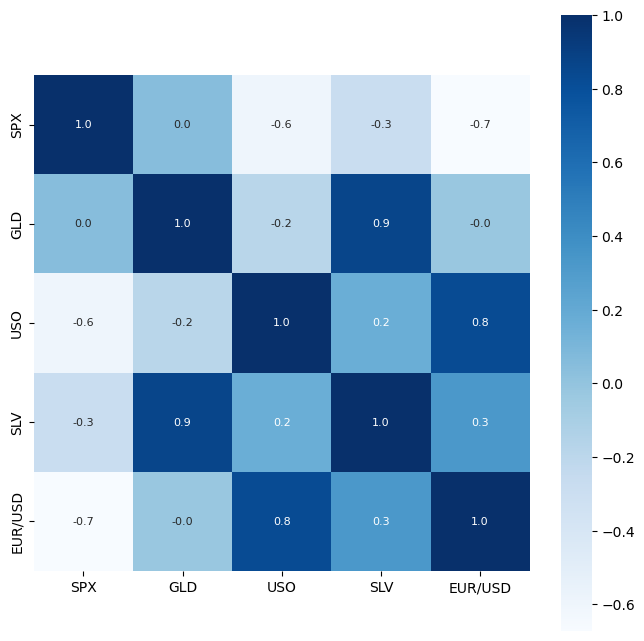

In [12]:
# constructing a heatmap to understand the correlations

plt.figure(figsize = (8,8))
sns.heatmap(correlations , cbar = True , square = True , fmt = ".1f" , annot = True , annot_kws = {"size":8} , cmap =  "Blues")

In [17]:
#correlations between gold and silver
print(correlations["GLD"])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


C:\Users\badgu\AppData\Local\Temp\ipykernel_2928\3381020241.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["GLD"],color = "green")


<Axes: xlabel='GLD', ylabel='Density'>

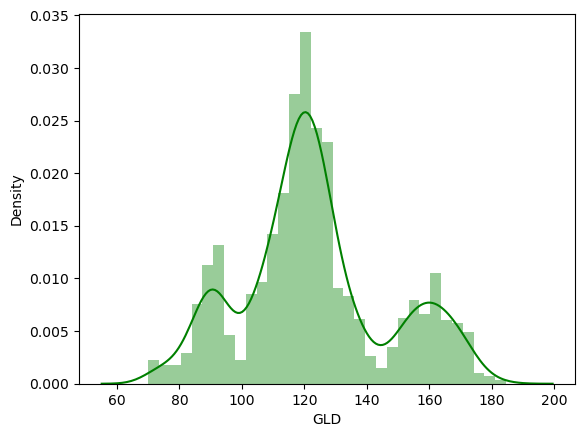

In [20]:
# checking the distribution of the gold price

sns.distplot(df["GLD"],color = "green")

# splitting the features and the target

In [21]:
X = df.drop(["GLD"],axis= 1)

In [22]:
Y = df["GLD"]

In [25]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [27]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


# splitting into training and test data

In [32]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y , test_size = 0.3 , random_state = 42
)

# model traning random forest regressor

In [33]:
rfr = RandomForestRegressor(n_estimators = 100)

In [34]:
#training the model

rfr.fit(X_train , Y_train)

RandomForestRegressor()

# model evaluation

In [35]:
#prediction on test data

prediction_for_test_data = rfr.predict(X_test)


In [36]:
print(prediction_for_test_data )

[122.50459922 130.30380283 127.76520006  97.6845992  119.10370036
 114.6059995  124.65460148 117.90449977 107.8059014   98.37959972
  96.01769973 167.6947983  148.97750125 115.958801   170.94980163
  85.15949935 123.97909918 108.8538973  112.44170064 131.62620275
 124.24439957 113.57400076 115.71760095 108.70350005 107.8683998
 125.74419971 119.58519959 112.48539859 113.32930179 126.21339898
 145.77560158  89.20350014 167.60839975 113.39029933 108.17810072
 120.27780058 141.74819864 161.34820167 174.04139858 153.02450125
 119.52360041 111.47900061 121.38929986 113.60939914 122.02143816
 107.95020103  88.06039892 114.1336993  129.6792019  117.89390094
 104.57839988 129.78400237 107.28419817 161.48390436 132.19350088
 117.95109939 146.4992994  135.22370189  95.52060032 124.55680187
 114.42659961  86.42910124 104.255299   113.69010027  84.43049916
 122.3247006  116.50449888 113.68910214 165.93240291  92.27740051
  79.83460125 161.0241008  158.04470287 107.29509995 149.35190122
 109.922997

In [41]:
# r2 score evaluation

r2_score = metrics.r2_score(Y_test , prediction_for_test_data)

In [42]:
print(r2_score)

0.9905549460323855


In [ ]:
prediction_for_test_data

In [43]:
Y_test = list(Y_test)

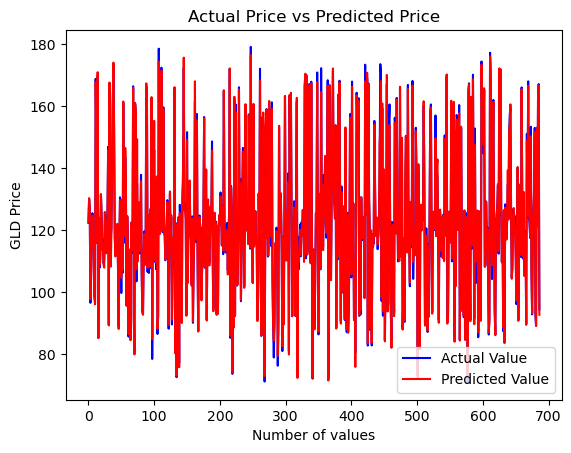

In [46]:
plt.plot(Y_test, color='blue', label = 'Actual Value')
plt.plot(prediction_for_test_data, color='red', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()